In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/spam (1).csv", encoding="latin-1")

In [10]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
#check dataset
print("Dtaset shape:",df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:", df.duplicated().sum())

Dtaset shape: (5572, 5)

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate Values: 403


In [12]:
#remove duplicates
df = df.drop_duplicates()

print("New Shape:",df.shape)

New Shape: (5169, 5)


In [14]:
df = df[['v1','v2']]
df.columns = ['label','text']

In [15]:
#convert labels
df["label"] = df["label"].map({
    "ham":0,
    "spam":1
})

df.head()

/tmp/ipykernel_1956/3477303803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["label"].map({


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


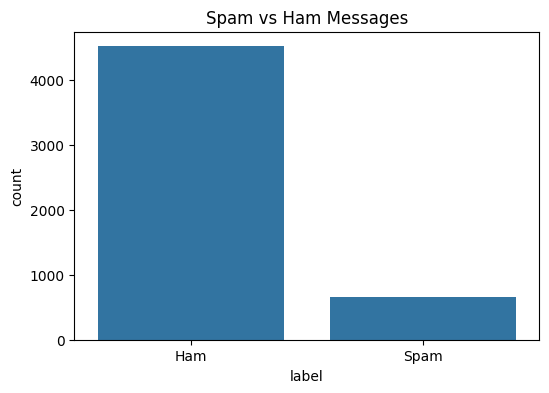

In [16]:
#count plot
plt.figure(figsize=(6,4))

sns.countplot(x=df["label"])

plt.xticks([0,1],["Ham","Spam"])

plt.title("Spam vs Ham Messages")

plt.show()


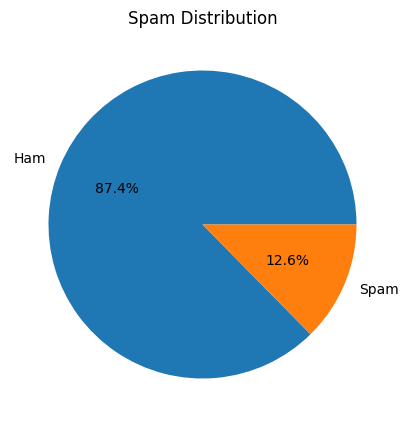

In [17]:
#pie chart
plt.figure(figsize=(5,5))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Ham","Spam"]
)
plt.ylabel("")

plt.title("Spam Distribution")

plt.show()

In [19]:
#split data
X=df["text"]

y=df["label"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
#nlp
vectorizer = TfidfVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [21]:
#Train Naive Bayes Model

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [22]:
#prediction
y_pred = model.predict(X_test)

In [23]:
#accuracy

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9661508704061895


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.76      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



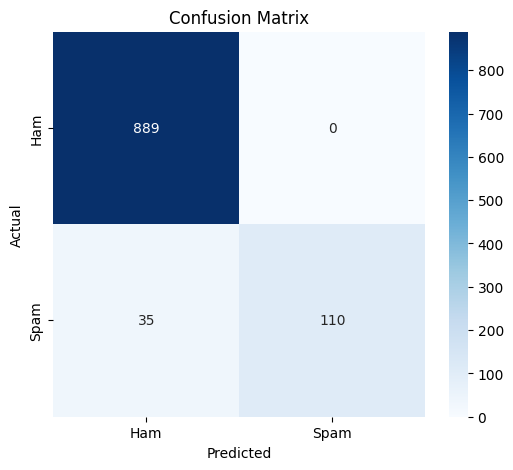

In [25]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [26]:
#predict your own message
while True:

    message = input("Enter Message (type 'exit' to stop): ")

    if message.lower() == "exit":
        break

    message_vector = vectorizer.transform([message])

    prediction = model.predict(message_vector)

    if prediction[0] == 1:
        print("🚫 Spam Message\n")

    else:
        print("✅ Ham Message\n")

Enter Message (type 'exit' to stop): congratulations! you won.
🚫 Spam Message

Enter Message (type 'exit' to stop): exit
